# **Week 2. Supervised Learning**

2주차 과제는 지도학습의 회귀, 분류 모델을 학습-평가하는 과정을 간소하게 재현한 코드입니다.

1. 적힌 코드를 따라가며, 배운 내용과 어떻게 연관되는지 등을 생각하거나 찾아본 후, 주석으로 달아주시면 좋을 것 같습니다.
2. 더불어 생각해볼 만한 질문들을 중간에 달아두었으니, 이에 대한 고민과 답변을 작성해주시면 됩니다.

# **1. 회귀 - with diabetes dataset**

In [1]:
# 필요한 라이브러리 불러오기
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import seaborn as sns
import matplotlib.pyplot as plt

## 1. 데이터 로드 및 탐색

In [2]:
diabetes = load_diabetes()
X, y = diabetes.data, diabetes.target # 입력 X, 정답 y
feature_names = diabetes.feature_names

In [3]:
print(diabetes) # diabates의 자료형은 Bunch라고 한다. 데이터를 꺼낼 때는 딕셔너리처럼 꺼낸다.

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
         0.01990749, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
        -0.06833155, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
         0.00286131, -0.02593034],
       ...,
       [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
        -0.04688253,  0.01549073],
       [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
         0.04452873, -0.02593034],
       [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
        -0.00422151,  0.00306441]]), 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
        69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
        68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
        87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
       259.,  53., 190., 142.,  75., 142., 155., 225.,  59., 104., 182.,
  

In [4]:
diabetes.keys() # 쓸 수 있는 주요 항목은 다음과 같다.

dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])

| 항목 | 자료형 | 의미 |
|---|---|---|
| `data` | NumPy 2차원 배열 | 환자 442명의 입력 특성 |
| `target` | NumPy 1차원 배열 | 환자별 당뇨병 진행도 |
| `feature_names` | 리스트 | 입력 특성 10개의 이름 |
| `DESCR` | 문자열 | 데이터셋에 관한 설명 |
| `frame` | DataFrame 또는 `None` | 표 형태의 데이터 |

In [5]:
# 데이터 크기와 피처(특성) 정보 출력
print(f"Dataset Shape: {X.shape}")  # (환자 수 , 특성 수)
print(f"Feature Names: {diabetes.feature_names}") # s1~s6은 혈청 관련 측정값
print(f"Target (y) Sample: {y[:5]}")  # 타겟 값 일부 확인 "0~4번 환자의 당뇨 진행도"

Dataset Shape: (442, 10)
Feature Names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Target (y) Sample: [151.  75. 141. 206. 135.]


In [6]:
# 데이터프레임으로 변환하여 탐색
df = pd.DataFrame(X, columns=feature_names) # 2차원 배열인 X를 dataframe으로
df['target'] = y # 마지막에 target 열도 추가

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [8]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


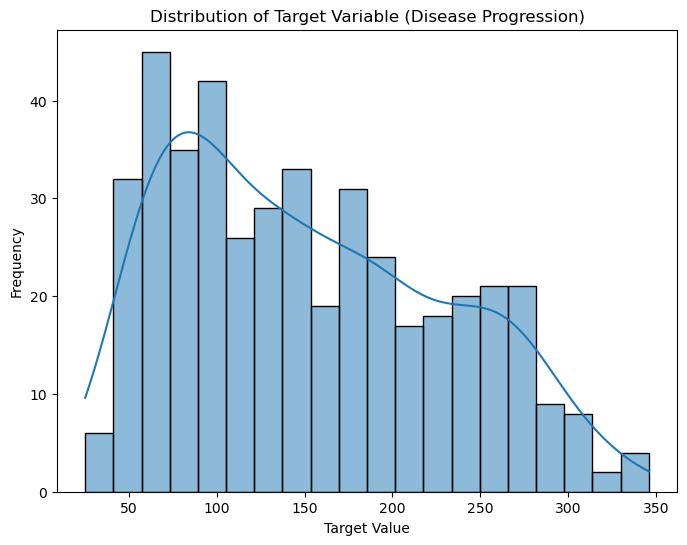

In [9]:
# 히스토그램으로 타겟 값 분포 확인
plt.figure(figsize=(8, 6))
sns.histplot(df['target'], bins=20, kde=True)
plt.title("Distribution of Target Variable (Disease Progression)")
plt.xlabel("Target Value")
plt.ylabel("Frequency")
plt.show()

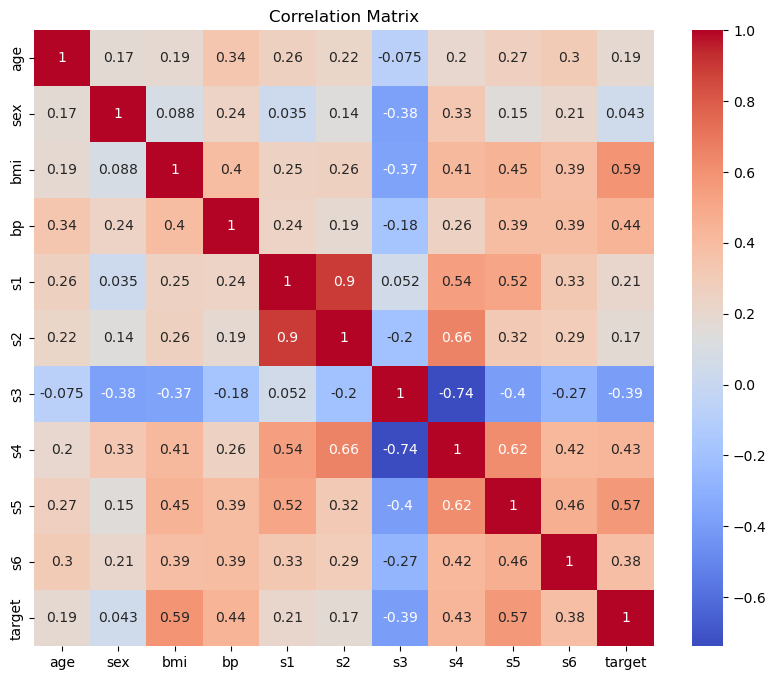

In [10]:
# 상관 행렬 및 히트맵 시각화
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [11]:
# Q1-1: 어떤 피처(특성)가 가장 중요한지, 직접 데이터를 분석해보세요.
# Q1-2: 어떤 피처가 'target'과 가장 높은 상관관계를 가지나요?

In [12]:
# 각 피처와 target 사이의 상관계수 계산
target_corr = (
    df.corr(numeric_only=True)['target']
    .drop('target')
    .sort_values(key=abs, ascending=False)
)

print("각 피처와 target의 상관계수:")
print(target_corr)

# 절댓값 기준으로 상관관계가 가장 큰 피처
most_correlated_feature = target_corr.index[0]
most_correlated_value = target_corr.iloc[0]

print("\ntarget과 가장 강한 상관관계를 가진 피처")
print(f"{most_correlated_feature}: {most_correlated_value:.3f}")

각 피처와 target의 상관계수:
bmi    0.586450
s5     0.565883
bp     0.441482
s4     0.430453
s3    -0.394789
s6     0.382483
s1     0.212022
age    0.187889
s2     0.174054
sex    0.043062
Name: target, dtype: float64

target과 가장 강한 상관관계를 가진 피처
bmi: 0.586


| 순위 | 피처 | 상관계수 | 해석 |
|---:|---|---:|---|
| 1 | `bmi` | 0.586 | BMI와 비례 |
| 2 | `s5` | 0.566 | s5(혈청 중성지방 관련 지표)와 비례 |
| 3 | `bp` | 0.441 | bp(혈압)와 비례 |
| 4 | `s4` | 0.430 | s4(총콜레스테롤/HDL 비율)와 비례 |
| 5 | `s3` | -0.395 | s3(HDL)과 반비례 |
| 6 | `s6` | 0.382 | s6(혈당)과 비례 |

### 결과 분석
분석 결과 target과 가장 높은 상관관계를 가진 피처는 bmi이며, 상관계수는 약 0.586으로 나타났다. 이는 BMI가 상대적으로 높은 환자일수록 1년 후 당뇨병 진행도도 높은 경향이 있음을 의미한다. 생명과학적으로 체지방, 특히 내장지방의 증가는 유리지방산 방출과 염증성 신호를 증가시켜 인슐린 저항성과 혈당 조절 이상을 유발할 수 있다.

그다음으로는 s5가 약 0.566의 양의 상관관계를 보였다. s5는 혈청 중성지방 관련 지표로, 인슐린 저항성과 동반되는 지질대사 이상을 반영할 수 있다. bp, s4, s6도 양의 상관관계를 보였으며, 이는 고혈압, 불리한 콜레스테롤 비율 및 높은 혈당이 당뇨병의 진행과 함께 나타나는 경향을 보여준다. 반면 HDL 관련 특성인 s3는 약 -0.395의 음의 상관관계를 보여, s3가 높을수록 진행도가 낮은 경향이 나타났다.

그러나 상관관계는 인과관계를 의미하지 않는다. 또한 이 분석은 각 피처를 개별적으로 비교한 것이므로 bmi가 다른 모든 변수를 고려한 후에도 가장 중요한 피처라고 단정할 수 없다. 모델의 회귀계수나 별도의 특성 중요도를 함께 분석해야 한다.

## 2. 데이터 전처리: 데이터 분할 및 스케일링


In [13]:
# 훈련 데이터와 테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
# Q2: 데이터 분할 비율을 70:30 또는 90:10으로 변경하면 결과는 어떻게 달라질까요?

In [15]:
split_results = []

for test_ratio in [0.3, 0.2, 0.1]:
    X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(
        X, y,
        test_size=test_ratio,
        random_state=42
    )

    scaler_temp = StandardScaler()
    X_train_temp = scaler_temp.fit_transform(X_train_temp)
    X_test_temp = scaler_temp.transform(X_test_temp)

    model_temp = LinearRegression()
    model_temp.fit(X_train_temp, y_train_temp)
    y_pred_temp = model_temp.predict(X_test_temp)

    split_results.append({
        "훈련:테스트": f"{int((1-test_ratio)*100)}:{int(test_ratio*100)}",
        "MSE": mean_squared_error(y_test_temp, y_pred_temp),
        "R²": r2_score(y_test_temp, y_pred_temp)
    })

pd.DataFrame(split_results)

,훈련:테스트,MSE,R²
0,70:30,2821.750981,0.477290
1,80:20,2900.193628,0.452603
2,90:10,2743.911238,0.551420


| 비율 | 훈련 샘플 | 테스트 샘플 | 특징 |
|---|---:|---:|---|
| 70:30 | 309 | 133 | 학습 데이터는 적지만 평가 결과는 비교적 안정적 |
| 80:20 | 353 | 89 | 중간 정도 |
| 90:10 | 397 | 45 | 학습 데이터는 많지만 평가 결과의 변동성이 큼 |

test 결과, 90:10의 성능이 가장 좋았다.(MSE가 작고 $R^2$ 이 크다.) 이는 train에 많은 환자의 데이터를 사용했기 때문에 당연한 결과다. 그러나 test 데이터가 45개밖에 되지 않아, 일부 환자의 특성에 따라 평가 지표가 크게 바뀔 가능성이 있어 보인다.

In [16]:
# 스케일링(표준화)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
# Q3: 스케일링을 하지 않고 학습하면 어떤 결과가 나올까요? 한 번 실험해 보세요.

In [18]:
# Q3: 스케일링한 경우와 하지 않은 경우 비교

# 같은 원본 데이터에서 다시 분할
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 1. 스케일링하지 않은 모델
model_without_scaling = LinearRegression()
model_without_scaling.fit(X_train_raw, y_train_raw)

y_pred_without_scaling = model_without_scaling.predict(X_test_raw)

mse_without_scaling = mean_squared_error(
    y_test_raw,
    y_pred_without_scaling
)
r2_without_scaling = r2_score(
    y_test_raw,
    y_pred_without_scaling
)

# 2. 스케일링한 모델
scaler_temp = StandardScaler()

X_train_scaled = scaler_temp.fit_transform(X_train_raw)
X_test_scaled = scaler_temp.transform(X_test_raw)

model_with_scaling = LinearRegression()
model_with_scaling.fit(X_train_scaled, y_train_raw)

y_pred_with_scaling = model_with_scaling.predict(X_test_scaled)

mse_with_scaling = mean_squared_error(
    y_test_raw,
    y_pred_with_scaling
)
r2_with_scaling = r2_score(
    y_test_raw,
    y_pred_with_scaling
)

# 결과 비교
comparison = pd.DataFrame({
    '모델': ['스케일링 없음', '스케일링 적용'],
    'MSE': [mse_without_scaling, mse_with_scaling],
    'R²': [r2_without_scaling, r2_with_scaling]
})

comparison

,모델,MSE,R²
0,스케일링 없음,2900.193628,0.452603
1,스케일링 적용,2900.193628,0.452603


일반적으로 변수의 측정 단위가 다르면 스케일링을 고려해야 한다. 그러나 Diabetes 데이터는 이미 각 특성의 평균과 크기가 조정되어 있어서 이번 실험에서는 스케일링 여부에 따라 MSE와 R²가 달라지지 않았다.

이는 아래 코드의 결과에서 확인할 수 있다. (이미 평균과 분산이 맞춰져있음)

In [19]:
feature_summary = pd.DataFrame({
    'mean': X.mean(axis=0),
    'std': X.std(axis=0)
}, index=feature_names)

feature_summary

,mean,std
age,-1.444295e-18,0.047565
sex,2.543215e-18,0.047565
bmi,-2.255925e-16,0.047565
bp,-4.854086e-17,0.047565
s1,-1.428596e-17,0.047565
s2,3.898811e-17,0.047565
s3,-6.028360e-18,0.047565
s4,-1.788100e-17,0.047565
s5,9.243486e-17,0.047565
s6,1.351770e-17,0.047565


## 3. 모델 적합 (선형 회귀)

In [20]:
model = LinearRegression()
model.fit(X_train, y_train)  # 학습 진행

# 모델의 가중치 출력
print("Model Coefficients:", model.coef_)
print("Model Intercept:", model.intercept_)

Model Coefficients: [  1.75375799 -11.51180908  25.60712144  16.82887167 -44.44885564
  24.64095356   7.67697768  13.1387839   35.16119521   2.35136365]
Model Intercept: 153.73654390934846


In [21]:
# Q4: 모델의 계수를 분석해보세요. 어떤 피처가 타겟에 가장 큰 영향을 미치는지 확인하세요.

In [22]:
# 각 피처의 회귀계수를 표로 정리
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': model.coef_
})

# 계수의 절댓값 추가
coef_df['abs_coefficient'] = coef_df['coefficient'].abs()

# 절댓값이 큰 순서로 정렬
coef_df = coef_df.sort_values(
    by='abs_coefficient',
    ascending=False
)

coef_df

,feature,coefficient,abs_coefficient
4,s1,-44.448856,44.448856
8,s5,35.161195,35.161195
2,bmi,25.607121,25.607121
5,s2,24.640954,24.640954
3,bp,16.828872,16.828872
7,s4,13.138784,13.138784
1,sex,-11.511809,11.511809
6,s3,7.676978,7.676978
9,s6,2.351364,2.351364
0,age,1.753758,1.753758


### 계수를 반영한 식
예측 진행도
= 153.74 + 1.75 × age - 11.51 × sex + 25.61 × bmi + 16.83 × bp - 44.45 × s1 + 24.64 × s2 + 7.68 × s3 + 13.14 × s4 + 35.16 × s5 + 2.35 × s6

### 영향력이 큰 변수들
표준화된 회귀계수의 절댓값 기준으로는 s1이 가장 크고, 양의 계수 중에서는 s5가 가장 크다. 

다만 s1부터 s5까지의 지질 관련 변수 사이에는 다중공선성이 있을 수 있으므로, s1의 큰 음의 계수를 생물학적 인과관계로 직접 해석해서는 안 된다.

### Q1에서와 Q4에서의 결과가 다른 이유
둘 다 "어떤 변수가 결과에 큰 영향을 주는가?"에 대한 답인데 결과가 달라서 왜 그럴까 생각을 해봤다. 

Q1에서는 target을 특성 하나씩과 비교한다. 즉, 다른 변수는 다 제끼고 한 지표씩 볼 때, BMI가 target과 가장 상관있던 변수였던 것이다.

반면 Q4에서는 다른 변수가 존재할 때, 어떤 변수가 중요한지를 보는 것이다. 즉, 다른 9개의 변수를 모두 고려한 상황에서 s1이 target에 큰 영향을 주는 것이다.

In [23]:
# 테스트 데이터로 예측
y_pred = model.predict(X_test)

## 4. 모델 평가 Evaluation

In [24]:
# 모델 평가

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score: {r2:.2f}")

Mean Squared Error (MSE): 2900.19
R² Score: 0.45


In [25]:
# (선택) Q5: MSE가 높거나 R² 점수가 낮다면, 데이터를 더 분석하거나 다른 모델을 시도해보세요.
# (선택) Q6: 선형 회귀 외에 Decision Tree, Random Forest를 사용해 결과를 비교해보세요.

### Q5에 대한 생각
현재 선형회귀 모델의 R²는 약 0.453으로, 당뇨병 진행도의 모든 변동을 충분히 설명하지는 못한다. 이는 생물학적 관계가 완전한 선형이 아니거나, 유전적 요인, 식습관, 운동량 및 약물 복용과 같은 중요한 변수가 데이터에 포함되지 않았기 때문일 수 있다. 성능 개선을 위해 비선형 모델, 규제 모델 및 교차검증을 시도할 수 있다.

In [26]:
# Q6 : 라이브러리 불러오기

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [27]:
# Q6: Linear Regression, Decision Tree, Random Forest 비교

models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )
}

results = []

for model_name, regression_model in models.items():
    regression_model.fit(X_train, y_train)
    prediction = regression_model.predict(X_test)

    results.append({
        'Model': model_name,
        'MSE': mean_squared_error(y_test, prediction),
        'R²': r2_score(y_test, prediction)
    })

results_df = pd.DataFrame(results)
results_df.sort_values('MSE')

,Model,MSE,R²
0,Linear Regression,2900.193628,0.452603
2,Random Forest,2959.180562,0.441469
1,Decision Tree,4887.000000,0.077603


Decision Tree는 진짜 쓰면 안 되겠다! 작은 훈련 데이터에 과적합되기 쉽다고 한다.

복잡하다고 꼭 좋은 것은 아니다. 데이터의 크기와 구조에 맞는 모델을 선택하자.

# 2. **분류 - with Iris dataset**

In [28]:
# 필요한 라이브러리 불러오기
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## 1. 데이터 로드 및 탐색

In [29]:
iris = load_iris()
X, y = iris.data, iris.target

feature_names = iris.feature_names
class_names = iris.target_names

In [30]:
# 데이터 크기와 피처 정보 출력
print(f"Dataset Shape: {X.shape}")  # (샘플 수, 피쳐 수) 
print(f"Feature Names: {iris.feature_names}")
print(f"Classes: {iris.target_names}")  # 클래스가 몇 개이고, 어떤 게 있는지 확인해 보세요
print(f"First 5 Samples:\n{X[:5]}")

Dataset Shape: (150, 4)
Feature Names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa' 'versicolor' 'virginica']
First 5 Samples:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


In [31]:
# Q1: 각 클래스에 몇 개의 데이터가 있는지 확인해 보세요. 클래스 별 데이터가 균등하게 분포되어 있나요?
unique, counts = np.unique(y, return_counts=True)
class_distribution = {int(k): int(v) for k, v in zip(unique, counts)}
print(f"Class Distribution: {class_distribution}")

Class Distribution: {0: 50, 1: 50, 2: 50}


네! 각 클래스당 50개씩으로 균등하게 분포되어 있습니다.

In [32]:
# 데이터프레임으로 변환하여 탐색
df = pd.DataFrame(X, columns=feature_names)
df['class'] = y

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   class              150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [34]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),class
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


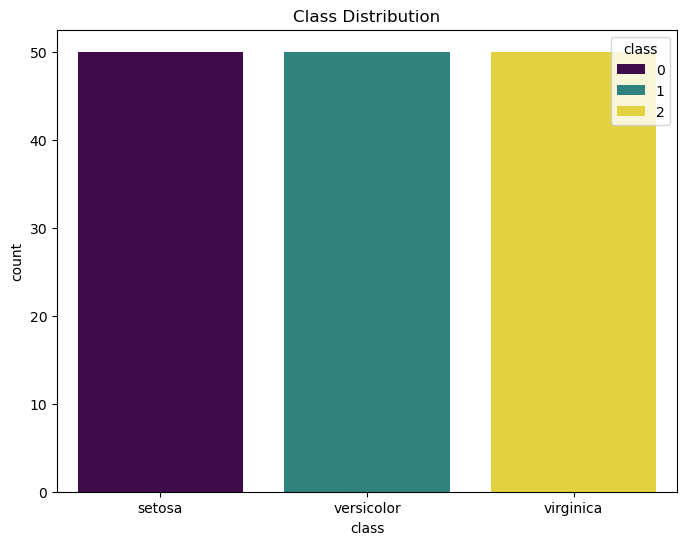

In [35]:
# 클래스별 데이터 분포 확인
plt.figure(figsize=(8, 6))
sns.countplot(x='class', data=df, palette='viridis', hue='class')
plt.title("Class Distribution")
plt.xticks(ticks=[0, 1, 2], labels=class_names)
plt.show()

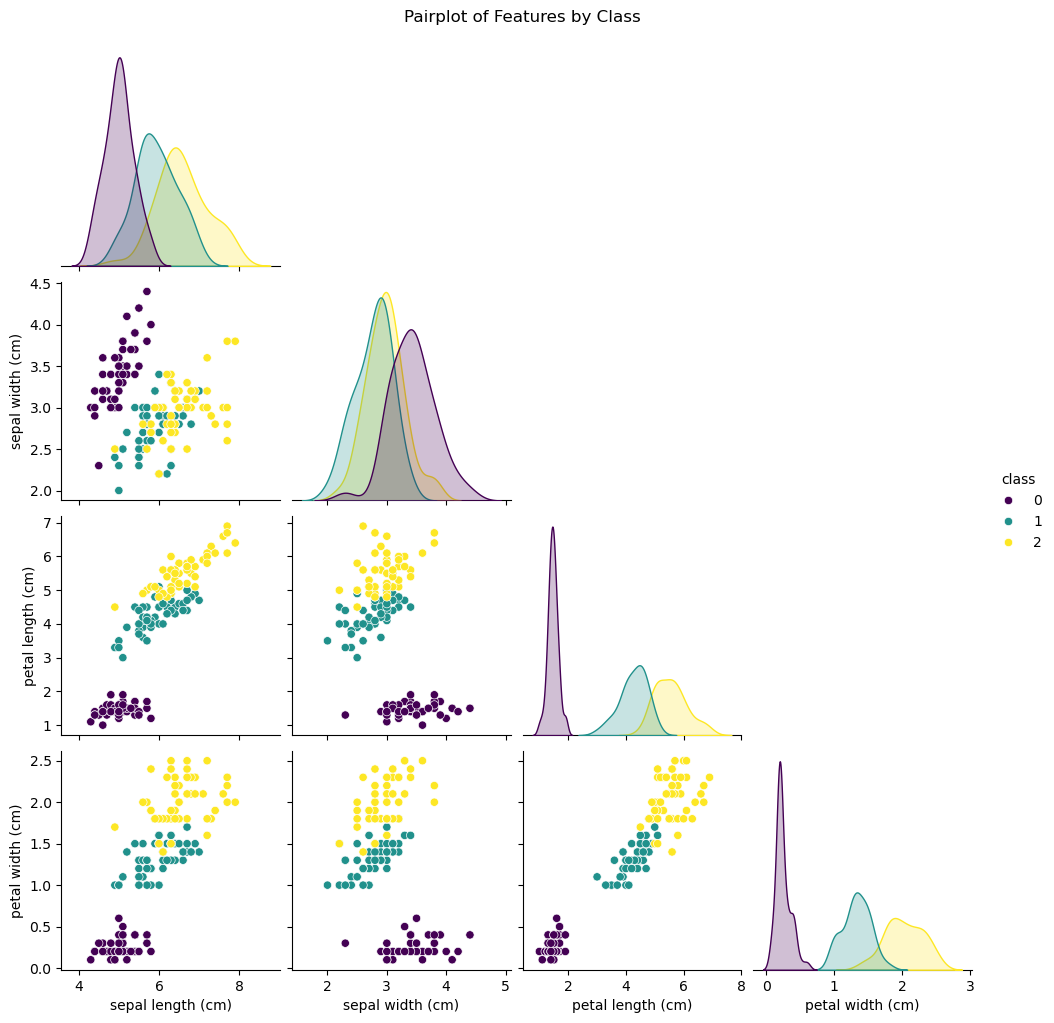

In [36]:
# 피처 간 산점도 행렬
sns.pairplot(df, hue='class', palette='viridis', diag_kind='kde', corner=True)
plt.suptitle("Pairplot of Features by Class", y=1.02)
plt.show()

## 2. 데이터 전처리: 데이터 분할 및 스케일링

In [37]:
# 훈련 데이터와 테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [38]:
# Q2: stratify를 제외하면 클래스 비율이 어떻게 달라질까요? 확인해 보세요.

stratify=y는 전체 데이터의 클래스 비율이 훈련 세트와 테스트 세트에서도 유지되도록 층화 추출하라는 의미다. 즉, 이 경우 훈련 세트는 클래스당 40개씩, 테스트 세트는 클래스당 10개씩으로 구성될 것이다.

In [39]:
# 클래스별 개수와 비율을 출력하는 함수
def print_class_distribution(data, data_name):
    unique, counts = np.unique(data, return_counts=True)

    print(f"\n{data_name}")
    
    for class_number, count in zip(unique, counts):
        ratio = count / len(data)

        print(
            f"{class_names[class_number]}: "
            f"{count}개 ({ratio:.1%})"
        )

In [40]:
# stratify를 적용한 분할
X_train_strat, X_test_strat, y_train_strat, y_test_strat = (
    train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )
)

# stratify를 적용하지 않은 분할
X_train_no_strat, X_test_no_strat, y_train_no_strat, y_test_no_strat = (
    train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )
)

print(" *** stratify 적용 시 ***")
print_class_distribution(y_train_strat, "훈련 세트")
print_class_distribution(y_test_strat, "테스트 세트")

print("\n *** stratify 미적용 시 ***")
print_class_distribution(y_train_no_strat, "훈련 세트")
print_class_distribution(y_test_no_strat, "테스트 세트")

 *** stratify 적용 시 ***

훈련 세트
setosa: 40개 (33.3%)
versicolor: 40개 (33.3%)
virginica: 40개 (33.3%)

테스트 세트
setosa: 10개 (33.3%)
versicolor: 10개 (33.3%)
virginica: 10개 (33.3%)

 *** stratify 미적용 시 ***

훈련 세트
setosa: 40개 (33.3%)
versicolor: 41개 (34.2%)
virginica: 39개 (32.5%)

테스트 세트
setosa: 10개 (33.3%)
versicolor: 9개 (30.0%)
virginica: 11개 (36.7%)


stratify=y를 적용했을 때 훈련 세트와 테스트 세트에서 원본 데이터의 비율이 유지되었다.
반면 stratify를 제외하고 분할한 결과, 훈련 세트의 클래스별 표본 수는 40개, 41개, 39개였으며 테스트 세트는 10개, 9개, 11개였다. 따라서 무작위 분할로 인해 클래스 비율에 작은 차이가 생겼다.

Iris 데이터는 클래스별 표본 수가 동일하여 차이가 크지 않았지만, 표본 수가 적거나 클래스 불균형이 심한 데이터에서는 특정 클래스가 훈련 또는 테스트 세트에 지나치게 적게 포함될 수 있다. 이는 모델 학습과 평가를 불안정하게 만들 수 있으므로, 분류 문제에서는 일반적으로 stratify=y를 사용해 클래스 비율을 유지하는 것이 적절하다.

In [41]:
# 스케일링(표준화)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [42]:
# Q3: 스케일링을 하지 않고 학습하면 정확도에 어떤 영향을 미칠까요?

In [43]:
# Q3: 스케일링 여부에 따른 SVM 성능 비교

# 동일한 원본 데이터 분할
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 스케일링 X
svm_without_scaling = SVC(
    kernel='linear',
    C=0.1
)

svm_without_scaling.fit(X_train_raw, y_train_raw)

y_pred_without_scaling = svm_without_scaling.predict(X_test_raw)

accuracy_without_scaling = accuracy_score(
    y_test_raw,
    y_pred_without_scaling
)

# 스케일링 O
scaler_temp = StandardScaler()

X_train_scaled = scaler_temp.fit_transform(X_train_raw)
X_test_scaled = scaler_temp.transform(X_test_raw)

svm_with_scaling = SVC(
    kernel='linear',
    C=0.1
)

svm_with_scaling.fit(X_train_scaled, y_train_raw)

y_pred_with_scaling = svm_with_scaling.predict(X_test_scaled)

accuracy_with_scaling = accuracy_score(
    y_test_raw,
    y_pred_with_scaling
)

# 결과 비교
comparison = pd.DataFrame({
    '모델': ['스케일링 없음', '스케일링 적용'],
    '정확도': [
        accuracy_without_scaling,
        accuracy_with_scaling
    ]
})

comparison

,모델,정확도
0,스케일링 없음,0.966667
1,스케일링 적용,0.933333


스케일링하지 않은 모델의 정확도는 약 0.967이고, 스케일링한 모델은 약 0.933의 정확도가 나왔다. 따라서 이번 한 번의 분할에서는 스케일링하지 않은 모델의 정확도가 더 높았다.

SVM은 특성 공간에서 거리와 마진을 이용해 결정경계를 만들기 때문에 일반적으로 스케일링에 민감하다. 스케일링하지 않으면 범위가 큰 특성이 결정경계에 더 큰 영향을 줄 수 있다. Iris 데이터에서는 품종 분류력이 높은 petal lenght의 수치 범위가 비교적 크기 때문에, 이러한 특성이 크게 반영된 것이 이번 테스트 세트에서 유리했을 가능성이 있다.

그러나 두 모델의 차이는 테스트 샘플 한 개에 불과하고, 테스트 데이터도 30개로 작다. 또한 데이터의 스케일이 바뀌면 같은 C=0.1의 효과도 달라진다. 따라서 이번 결과만으로 스케일링하지 않는 것이 더 좋다고 일반화할 수는 없겠다.

## 3. 모델 적합 (SVM)

In [44]:
model = SVC(kernel='linear', C=0.1)  # 선형 커널 사용
model.fit(X_train, y_train)  # 모델 학습

SVC(C=0.1, kernel='linear')

In [45]:
# Q4: C 값을 조정해보세요 (예: 0.1, 10). 모델의 성능에 어떤 영향을 미칠까요?

In [46]:
# Q4: C 값에 따른 SVM 성능 비교

C_values = [0.01, 0.1, 1, 10, 100] # 다양한 C 값
results = []

for c_value in C_values:
    svm_model = SVC(
        kernel='linear',
        C=c_value
    )

    svm_model.fit(X_train, y_train)

    train_pred = svm_model.predict(X_train)
    test_pred = svm_model.predict(X_test)

    results.append({
        'C': c_value,
        '훈련 정확도': accuracy_score(y_train, train_pred),
        '테스트 정확도': accuracy_score(y_test, test_pred),
        '서포트 벡터 수': svm_model.n_support_.sum()
    })

results_df = pd.DataFrame(results)
results_df

,C,훈련 정확도,테스트 정확도,서포트 벡터 수
0,0.01,0.891667,0.866667,106
1,0.10,0.975000,0.933333,56
2,1.00,0.975000,1.000000,23
3,10.00,0.975000,0.966667,14
4,100.00,0.983333,1.000000,11


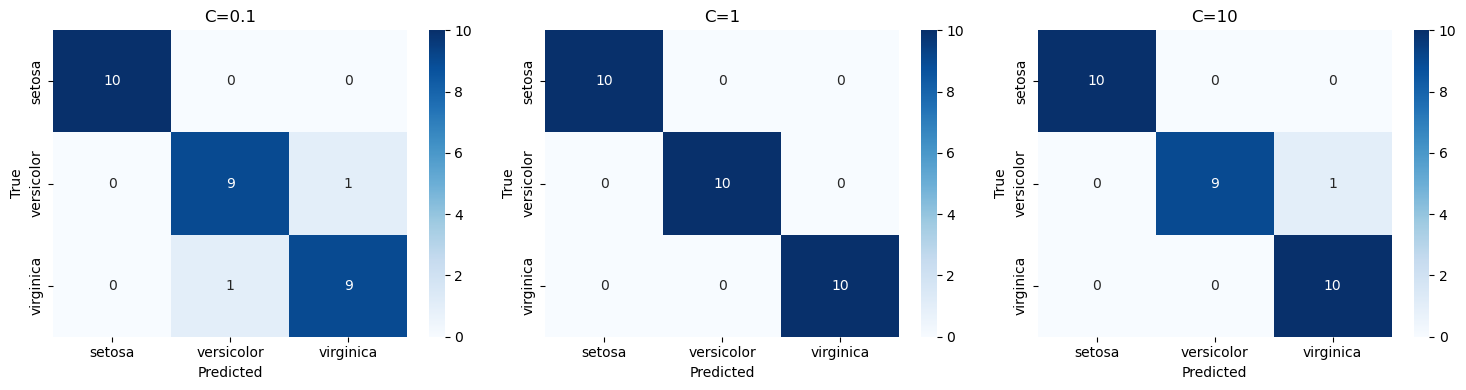

In [47]:
# C가 0.1, 1, 10일 때 성능 비교 시각화하기

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, c_value in zip(axes, [0.1, 1, 10]):
    svm_model = SVC(kernel='linear', C=c_value)
    svm_model.fit(X_train, y_train)

    y_pred_temp = svm_model.predict(X_test)
    cm_temp = confusion_matrix(y_test, y_pred_temp)

    sns.heatmap(
        cm_temp,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax
    )

    ax.set_title(f"C={c_value}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
plt.show()

C가 작으면 오분류를 어느 정도 허용하면서 넓은 마진을 선택하므로 규제가 강해진다. 따라서 새로운 데이터에 안정적일 수 있지만, 너무 작으면 모델이 충분히 학습하지 못해 과소적합이 발생할 수 있다. 

반대로 C가 크면 훈련 데이터의 오분류를 강하게 줄이려고 하므로 규제가 약해지고 마진이 좁아진다. 이는 훈련 데이터를 더 잘 구분할 수 있지만 노이즈와 특이 표본에 민감해져 과적합될 가능성이 있다.

이번 실험에서는 C=0.1보다 C=10의 성능이 높았지만, 테스트 표본이 30개로 작아 한두 개의 예측만으로 정확도가 크게 달라진다. 따라서 특정 테스트 결과만으로 최적의 C를 결정하기보다 교차검증을 이용해 선택하는 것이 적절하다.

In [48]:
# 테스트 데이터로 예측
y_pred = model.predict(X_test)

In [49]:
print(y_pred)
print(class_names[y_pred])

[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 1 2 2 1 0 2 0]
['setosa' 'virginica' 'versicolor' 'versicolor' 'setosa' 'versicolor'
 'setosa' 'setosa' 'virginica' 'versicolor' 'virginica' 'virginica'
 'virginica' 'versicolor' 'setosa' 'setosa' 'setosa' 'versicolor'
 'versicolor' 'virginica' 'setosa' 'virginica' 'versicolor' 'versicolor'
 'virginica' 'virginica' 'versicolor' 'setosa' 'virginica' 'setosa']


## 4. 모델 평가 Evaluation 

In [50]:
# 모델 평가
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Accuracy: 0.93

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



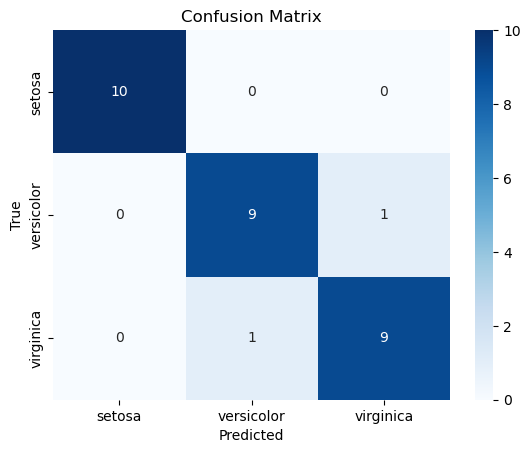

In [51]:
# Confusion Matrix 시각화
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [52]:
# Q6: Confusion Matrix를 보고 결과를 해석해보세요.

Confusion Matrix를 분석한 결과, 테스트 데이터 30개 중 28개를 정확하게 분류하여 전체 정확도는 약 93.3%였다. 실제 setosa 10개는 모두 setosa로 정확하게 분류되었다. 실제 versicolor 10개 중 9개는 정확하게 분류되었고 1개는 virginica로 오분류되었다. 실제 virginica 10개 중 9개는 정확하게 분류되었으며 1개는 versicolor로 오분류되었다.

setosa는 꽃잎 길이와 너비가 다른 두 품종보다 뚜렷하게 작기 때문에 쉽게 구분된 것으로 보인다. 반면 versicolor와 virginica는 꽃잎과 꽃받침 측정값의 일부 범위가 겹치므로 서로 혼동되었다. 이는 생물학적 개체 간 변이와 선형 SVM 결정경계의 한계가 함께 반영된 결과일 수 있다.

결론적으로 모델은 setosa를 완벽하게 분류했으며 전체적으로도 높은 성능을 보였지만, 형태적 특징이 유사한 versicolor와 virginica 사이에서는 소수의 오분류가 발생했다.